## Indicators in jarjarquant

This notebook goes over how indicators are implemented in jarjarquant, how they can be used, and the common indicator workflows

---

In [87]:
# Always start with importing the Jarjarquant class and initializing an instance
from jarjarquant import Jarjarquant
import logging

# Set global log level
logging.basicConfig(
    level=logging.INFO,  # Can be INFO, WARNING, ERROR
    format="%(asctime)s [%(levelname)s] %(name)s: %(message)s"
)

jjq = Jarjarquant()

---
The `list_indicator()` method provides an easy way to look at available indicators

In [88]:
jjq.list_indicators()

[<IndicatorType.ADX: 'adx'>,
 <IndicatorType.ANCHORED_VWAP: 'anchored_vwap'>,
 <IndicatorType.AROON: 'aroon'>,
 <IndicatorType.CHAIKIN_MONEY_FLOW: 'chaikin_money_flow'>,
 <IndicatorType.CMMA: 'cmma'>,
 <IndicatorType.RSI: 'rsi'>,
 <IndicatorType.DETRENDED_RSI: 'detrended_rsi'>,
 <IndicatorType.GAP_SIZE: 'gap_size'>,
 <IndicatorType.MACD: 'macd'>,
 <IndicatorType.MOVING_AVERAGE_DIFFERENCE: 'moving_average_difference'>,
 <IndicatorType.PRICE_CHANGE_OSCILLATOR: 'price_change_oscillator'>,
 <IndicatorType.PRICE_INTENSITY: 'price_intensity'>,
 <IndicatorType.REGRESSION_TREND: 'regression_trend'>,
 <IndicatorType.REGRESSION_TREND_DEVIATION: 'regression_trend_deviation'>,
 <IndicatorType.STOCHASTIC: 'stochastic'>,
 <IndicatorType.STOCHASTIC_RSI: 'stochastic_rsi'>]

---
In jarjarquant, each indicator is registered as an `IndicatorType`, which allows for type hints in the editor for a better developer experience. IndicatorType objects can also be used to get details about an indicator using utility method: `get_indicator_parameters()` 

In [89]:
from jarjarquant import IndicatorType, get_indicator_parameters
import json

gap_size_params = get_indicator_parameters(IndicatorType.PRICE_INTENSITY)
print(json.dumps(gap_size_params, indent=2, default=str))

{
  "ohlcv_df": {
    "type": "<class 'polars.dataframe.frame.DataFrame'>",
    "required": true,
    "default": null
  },
  "smoothing_factor": {
    "type": "<class 'int'>",
    "required": false,
    "default": 2
  },
  "transform": {
    "type": "Any",
    "required": false,
    "default": null
  }
}


In [90]:
# Define a spec for the indicator - change any default values if needed
from jarjarquant import IndicatorSpec
cmf = IndicatorSpec(IndicatorType.PRICE_INTENSITY, parameters={"smoothing_factor": 2})

### Eye balling the indicator for good design

In [95]:
from jarjarquant import BarSize, SampleRequest
from jarjarquant.data_service import DataService

# Import the SampleRequest class and specify asset_class, date_range, bar_sizes, and any asset_class specific filters
params = None
random_sample = SampleRequest(sample_type="equities", start_date="2010-01-01", end_date="2019-12-31", bar_size=BarSize.ONE_HOUR, n_samples = 1, params=params)

ds = DataService()

sample_data = ds.get_sample(random_sample).data

2026-02-15 23:10:43,760 [INFO] jarjarquant.data_service: Registered equities_metadata view


In [96]:
cmf_values = cmf.create_indicator(sample_data).calculate()

ValueError: Please provide a valid OHLCV DataFrame!

In [97]:
import matplotlib.pyplot as plt
plt.plot(sample_data["date"], cmf_values)
plt.xlabel("Date")
plt.ylabel("CMF")
plt.title("CMF Over Time")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

ColumnNotFoundError: "date" not found

---
### Indicator Design Evaluation Workflow

A common workflow in early stages of quantitative system development is to evaluate an indicator's design - as opposed to it's performance. A well designed indicator has good statistical properties (stationarity, normality, high entropy) across assets and regimes, which makes it suitable for machine learning algorithms and even rule based systems.

To evaluate an indicator across multiple samples use the `parallel_indicator_distribution_study()` method from `jjq.feature_evaluator`. The workflow looks slightly different based on the data source, but can broadly be broken down into 3 categories based on the type of data source: 1. External API, 2. Custom (Local) Data and 3. Synthetic Data 

#### 1. External API

#### 2. Custom (local) data

In [99]:
# Import the SampleRequest class and specify asset_class, date_range, bar_sizes, and any asset_class specific filters
from jarjarquant.data_service import EquityParams

equity_sample = SampleRequest(sample_type="equities", start_date="2006-01-01", end_date="2019-12-31", bar_size=BarSize.ONE_HOUR, n_samples = 50, params=params)

In [100]:
print(jjq.feature_evaluator.parallel_indicator_distribution_study(cmf, equity_sample))

2026-02-15 23:11:01,345 [INFO] jarjarquant.feature_evaluator: Sample request setup time: 0.0000s
2026-02-15 23:11:01,345 [INFO] jarjarquant.feature_evaluator: Checking for existing results in database...
2026-02-15 23:11:01,384 [INFO] jarjarquant.data_service: Registered equities_metadata view
2026-02-15 23:11:01,418 [INFO] jarjarquant.feature_evaluator: No existing results found for the given parameters.
2026-02-15 23:11:01,419 [INFO] jarjarquant.feature_evaluator: No existing results found. Running new study...
2026-02-15 23:11:01,647 [INFO] jarjarquant.feature_evaluator: Data gathering time: 0.2276s
2026-02-15 23:11:01,650 [INFO] jarjarquant.feature_evaluator: Data preparation time: 0.0020s
2026-02-15 23:11:01,651 [INFO] jarjarquant.feature_evaluator: Processing 0 ticker datasets
2026-02-15 23:11:01,653 [INFO] jarjarquant.feature_evaluator: Parallel processing time: 0.0020s


ValueError: Error saving evaluation results: No valid rows were extracted.

In [ ]:
ds.load_from_database("ind_dist_studies_db")

---

### Single Indicator Evaluation Workflow

Once a set of primary indicator specs is selected, a comprehensive suite of performance evaluation tests can be run on a specified sample. 

To evaluate performance we need to generate signals. Signals in jarjarquant are straightforward since they rely on an underlying assumption: **the indicator design workflow ensures only stable, high entropy indicators continue to the evaluation phase.** 

In essence, the indicator is designed to capture information in the extremes. An indicator, for example, CMMA (close minus moving average) that contains "significant information" when the values are extremely positive or negative is a well-designed indicator. This should be kept in mind when designing indicators.

The single indicator evaluation pipeline consists of the following:
- Define thresholds (either static or rolling) that will generate signals.
- Initial performance (spec + thresholds) on sample: Profit Factor, Accuracy, Payoff Ratio, Turnover (trades generated), Sharpe Ratio
- Optimized threshold performance with Monte Carlo permutation based p-values

In [76]:
df = jjq.feature_evaluator.parallel_threshold_optimization_study(cmf, equity_sample, save_run=False)

2026-02-14 18:54:49,834 [INFO] jarjarquant.feature_evaluator: Sample request setup time: 0.0000s
2026-02-14 18:54:49,834 [INFO] jarjarquant.feature_evaluator: No existing results found. Running new study...
2026-02-14 18:54:50,073 [INFO] jarjarquant.feature_evaluator: Data gathering time: 0.2375s
2026-02-14 18:54:50,076 [INFO] jarjarquant.feature_evaluator: Data preparation time: 0.0030s
2026-02-14 18:54:50,077 [INFO] jarjarquant.feature_evaluator: Processing 29 ticker datasets
2026-02-14 18:54:55,150 [INFO] jarjarquant.feature_evaluator: Parallel processing time: 5.0734s
2026-02-14 18:54:55,151 [INFO] jarjarquant.feature_evaluator: Total parallel_threshold_optimization_study time: 5.3170s


Text(0.5, 1.0, 'Best PF P-Value')

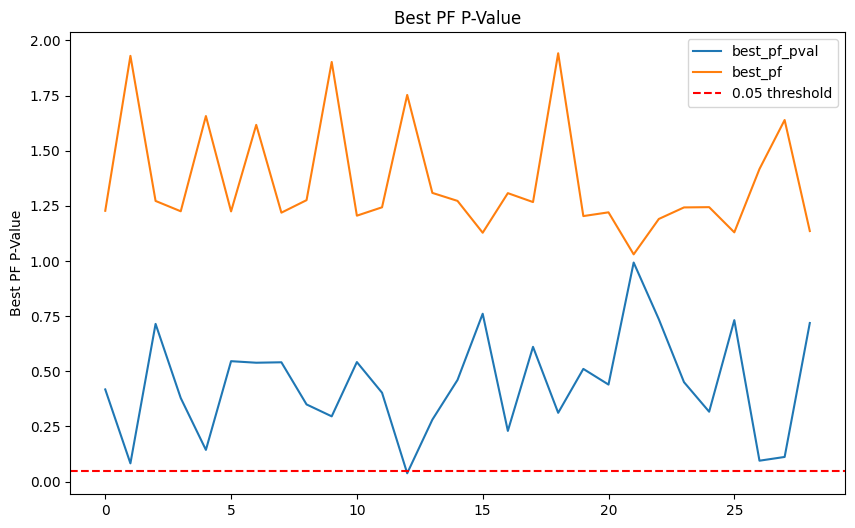

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
df_pandas = df.to_pandas()
df_pandas["best_pf_pval"].plot()
df_pandas["best_pf"].plot()
plt.axhline(0.05, color='red', linestyle='--', linewidth=1.5, label='0.05 threshold')
plt.legend()
plt.ylabel('Best PF P-Value')
plt.title('Best PF P-Value')

In [57]:
df = df.to_pandas()

In [58]:
sum(df['optimal_long_pf']==df['best_pf'])/len(df)

0.8461538461538461

In [60]:
# use pandas Series method to compute mean
df['optimal_long_acc'].mean()

np.float64(0.5270877546887937)

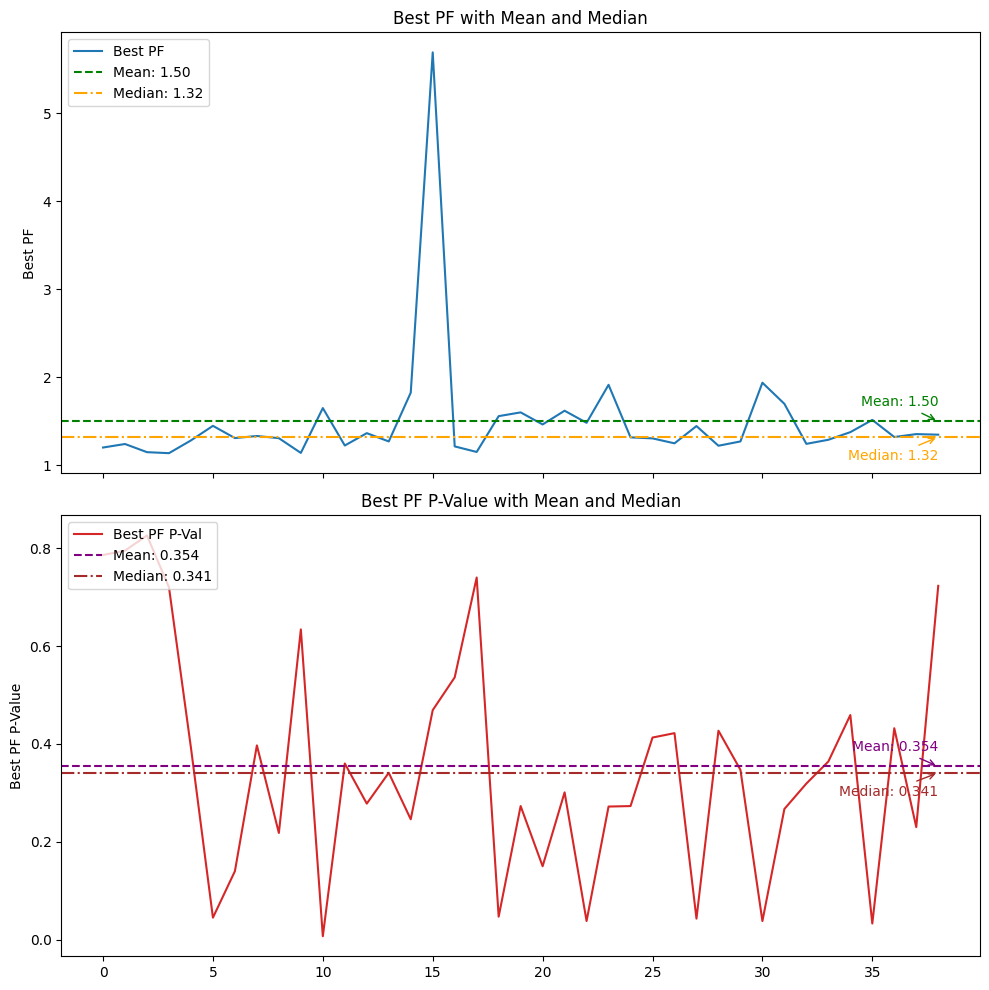

In [61]:
import matplotlib.pyplot as plt

# Create two subplots sharing the x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# --- Plot 1: Best PF ---
df['best_pf'].plot(ax=ax1, title='Best PF with Mean and Median', label='Best PF', color='tab:blue')
ax1.set_ylabel('Best PF')

mean_val = df['best_pf'].mean()
median_val = df['best_pf'].median()

# horizontal lines with labels for Best PF
ax1.axhline(mean_val, color='green', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.2f}')
ax1.axhline(median_val, color='orange', linestyle='-.', linewidth=1.5, label=f'Median: {median_val:.2f}')

# compute a small vertical offset for annotation placement
y_range = df['best_pf'].max() - df['best_pf'].min()
y_offset = y_range * 0.03 if y_range > 0 else 1.0

# annotate lines (pointing to the rightmost x)
x_pos = len(df) - 1
ax1.annotate(f'Mean: {mean_val:.2f}', xy=(x_pos, mean_val), xytext=(x_pos, mean_val + y_offset),
            ha='right', va='bottom', color='green', arrowprops=dict(arrowstyle='->', color='green'))
ax1.annotate(f'Median: {median_val:.2f}', xy=(x_pos, median_val), xytext=(x_pos, median_val - y_offset),
            ha='right', va='top', color='orange', arrowprops=dict(arrowstyle='->', color='orange'))

ax1.legend(loc='upper left')

# --- Plot 2: Best PF P-Value ---
df['best_pf_pval'].plot(ax=ax2, title='Best PF P-Value with Mean and Median', label='Best PF P-Val', color='tab:red')
ax2.set_ylabel('Best PF P-Value')

pval_mean = df['best_pf_pval'].mean()
pval_median = df['best_pf_pval'].median()

# horizontal lines with labels for P-Value
ax2.axhline(pval_mean, color='purple', linestyle='--', linewidth=1.5, label=f'Mean: {pval_mean:.3f}')
ax2.axhline(pval_median, color='brown', linestyle='-.', linewidth=1.5, label=f'Median: {pval_median:.3f}')

# compute offset for p-value annotations
y_range_pval = df['best_pf_pval'].max() - df['best_pf_pval'].min()
y_offset_pval = y_range_pval * 0.03 if y_range_pval > 0 else 0.01

# annotate p-value lines
ax2.annotate(f'Mean: {pval_mean:.3f}', xy=(x_pos, pval_mean), xytext=(x_pos, pval_mean + y_offset_pval),
             ha='right', va='bottom', color='purple', arrowprops=dict(arrowstyle='->', color='purple'))
ax2.annotate(f'Median: {pval_median:.3f}', xy=(x_pos, pval_median), xytext=(x_pos, pval_median - y_offset_pval),
             ha='right', va='top', color='brown', arrowprops=dict(arrowstyle='->', color='brown'))

ax2.legend(loc='upper left')

fig.tight_layout()

In [62]:
df['best_pf'].median()

np.float64(1.32162020494433)

In [63]:
df[(df['optimal_long_pf']==df['best_pf'])]['best_pf_pval'].median()

np.float64(0.319)

In [79]:
percent_below_005 = (df['best_pf_pval'] < 0.05).mean() * 100
print(f"{percent_below_005:.2f}%")

3.45%


In [80]:
df[df['best_pf_pval'] < 0.05]

ValueError: expected 10 values when selecting columns by boolean mask, got 29